###### Perform Exploratory Data Analysis of the given dataset and prepare an Executive Summary
###### Dataset was provided as part of https://www.coursera.org/professional-certificates/google-advanced-data-analytics

In [112]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [113]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  # Ignore the unnecessary noise of future warnings in the output

In [114]:
os.chdir("../Data")
# os.getcwd()
# Read the input csv file into a dataframe

In [115]:
wazedf = pd.read_csv("Waze_dataset.csv")
# Validate the Stats of the numerical columns in the dataset
wazedf.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [116]:
# Validate the Stats of all the columns in the dataset
wazedf.describe(include='all')

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
count,14999.000000,14299,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,retained,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,iPhone
freq,NaN,11763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9672
mean,7499.000000,NaN,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879,NaN
std,4329.982679,NaN,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036,NaN
min,0.000000,NaN,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,NaN
25%,3749.500000,NaN,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,NaN
50%,7499.000000,NaN,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,NaN
75%,11248.500000,NaN,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,NaN


In [117]:
# View a sample of the data
wazedf.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [118]:
# Number of rows and columns in the dataset
wazedf.shape

(14999, 13)

In [119]:
# Check the datatypes and non-null counts in dataset
wazedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [120]:
#Find the columns that have null values
wazedf.isnull().sum()

ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

In [121]:
# Function that displays the outliers and distribution of each of the columns
def show_outliers_n_distribution(colname):
    plt.figure(figsize =(1,3))
    sn.boxplot(y=wazedf[colname])
    plt.show
    
    plt.figure(figsize=(7,3))
    sn.histplot(x=wazedf[colname])
    plt.axvline(wazedf[colname].median(), color = 'red', linestyle = '--')
    median = wazedf[colname].median()
    # mean = wazedf['sessions'].mean()
    #plt.text(80, 1200, 'median='+ str(median), color = 'red')
    plt.title('Median of ' + colname + ' is:' + str(median))
    plt.show

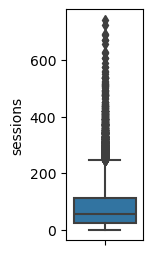

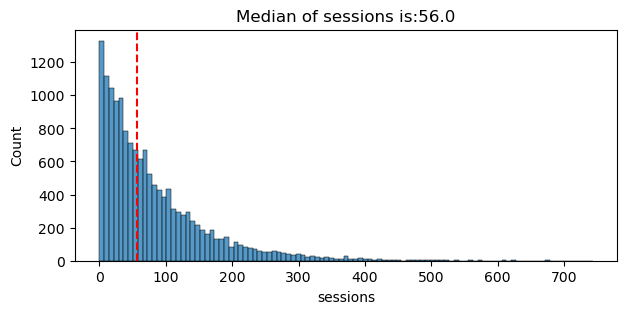

In [122]:
# find outliers and distribution of the Sessions variable
show_outliers_n_distribution('sessions')
# 50% of users have 56 or lesser number of sessions

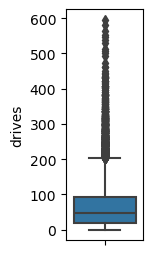

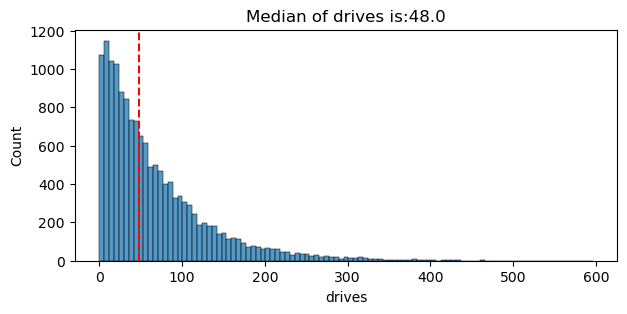

In [123]:
# find outliers and distribution of the drives variable
show_outliers_n_distribution('drives')
# 50% of users have 48 or lesser number of drives

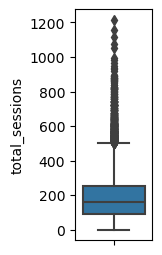

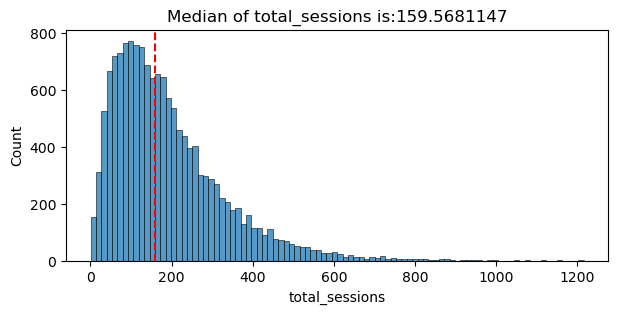

In [124]:
# find outliers and distribution of the total_sessions variable
show_outliers_n_distribution('total_sessions')
# 50% users have 159 total sessions or less

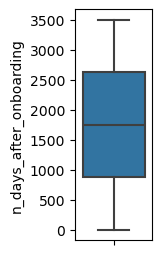

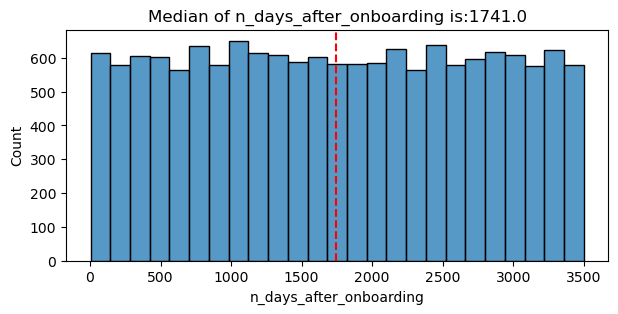

In [125]:
# find outliers and distribution of the n_days_after_onboarding variable
show_outliers_n_distribution('n_days_after_onboarding')
# number of days since a user signed up has uniform distibution

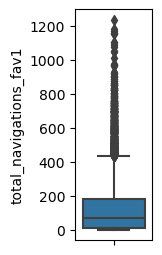

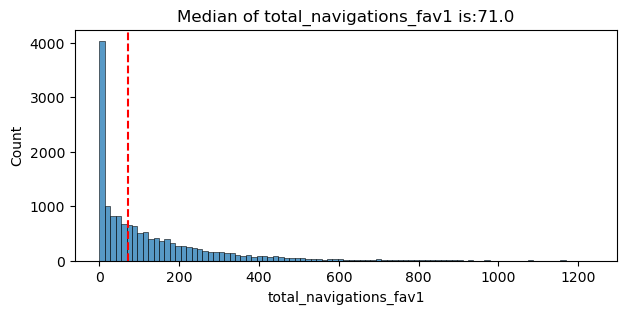

In [126]:
# find outliers and distribution of the total navigations to favorite place1 variable
show_outliers_n_distribution('total_navigations_fav1')
# 50% of users have navigated to their favorite place only 71 times, though there are users who have navigated 1000 times or higher

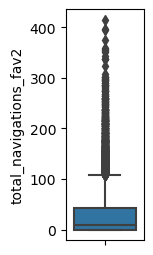

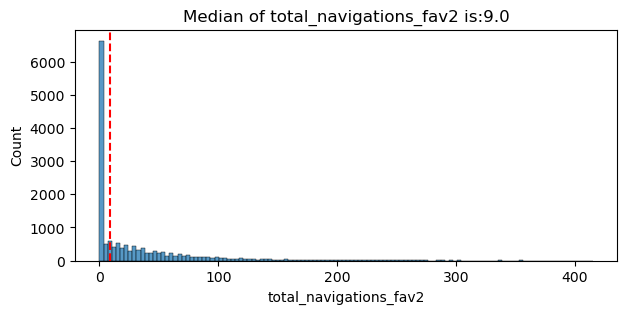

In [127]:
# find outliers and distribution of the total navigations to favorite place2 variable
show_outliers_n_distribution('total_navigations_fav2')
# 50% of users have navigated to their 2nd favorite place only 9 times, though there are users who have navigated 300 or more times

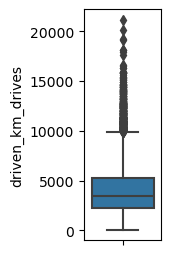

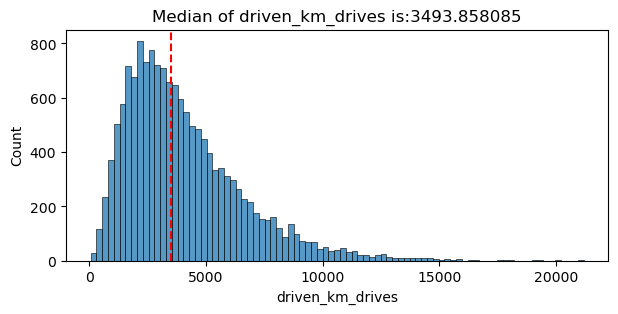

In [128]:
# find outliers and distribution of the total kilometers driven during the month
show_outliers_n_distribution('driven_km_drives')
# 50% of users drove 3493 km or lesser during the month

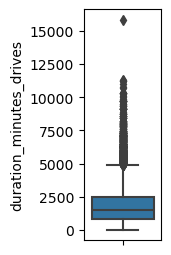

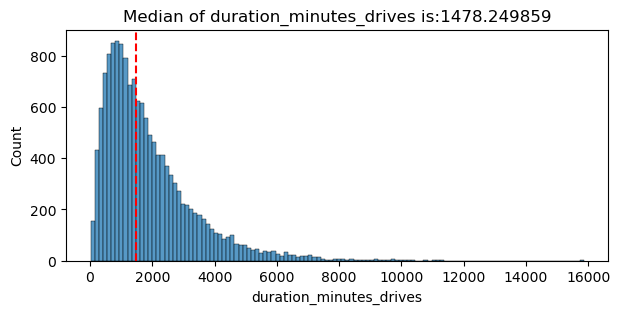

In [129]:
# find outliers and distribution of the total duration driven in minutes during the month
show_outliers_n_distribution('duration_minutes_drives')
# 50% of users drove less than 1478 minutes during the month

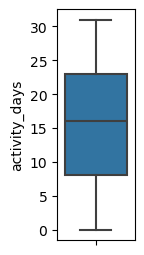

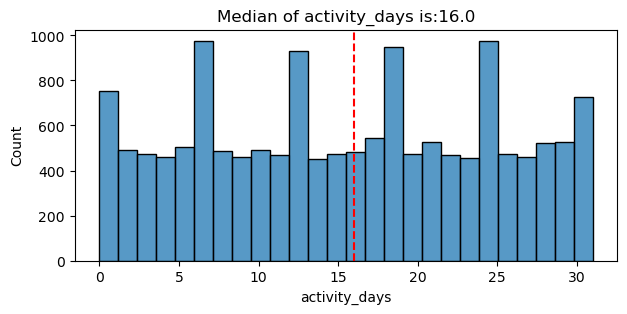

In [130]:
# find outliers and distribution of the Number of days the user opens the app during the month 
show_outliers_n_distribution('activity_days')
# Looks users have a uniform pattern of using the app

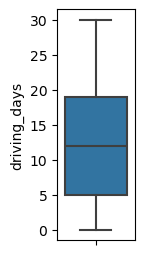

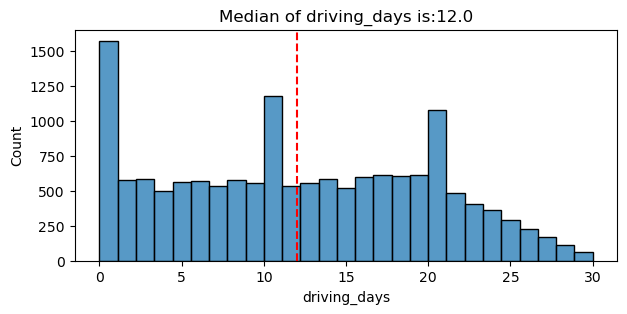

In [131]:
# find outliers and distribution of the Number of days the user drives (at least 1 km) during the month 
show_outliers_n_distribution('driving_days')
# Though users opening the app during the month is uniform throughout the month, the number of users driving atleast 1km falls off steeply after 23 days

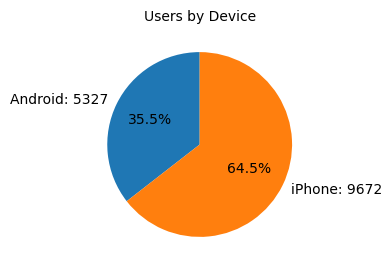

In [132]:
#Device is a categorical variable, and has only 2 distinct values
plt.figure(figsize =(3,3))
dvc_counts = wazedf['device'].value_counts(ascending=True)
dvc_labels = [f'{dvc_counts.index[0]}: {dvc_counts.values[0]}',
             f'{dvc_counts.index[1]}: {dvc_counts.values[1]}']
plt.pie(dvc_counts, labels=dvc_labels, autopct = '%1.1f%%', startangle = 90)
plt.title('Users by Device', fontsize=10)
plt.show()
#Approx.65% of users have their app installed in an iPhone, which is almost twice that of Android users

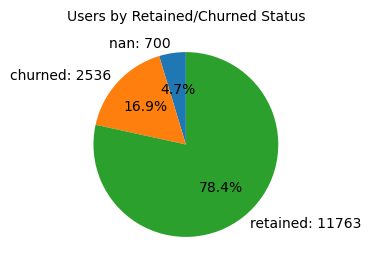

In [133]:
#Label is also a categorical variable, and has only 2 distinct values
plt.figure(figsize =(3,3))
label_counts = wazedf['label'].value_counts(dropna=False, ascending=True)   # <-- This is to get the Null values in the distribution
label_nm = [f'{label_counts.index[0]}: {label_counts.values[0]}',
             f'{label_counts.index[1]}: {label_counts.values[1]}',
             f'{label_counts.index[2]}: {label_counts.values[2]}']
plt.pie(label_counts, labels=label_nm, autopct = '%1.1f%%', startangle=90)
plt.title('Users by Retained/Churned Status', fontsize=10)
plt.show()
# ~17% users have churned, Need to identify the status of the 4.7% users whose status is missing

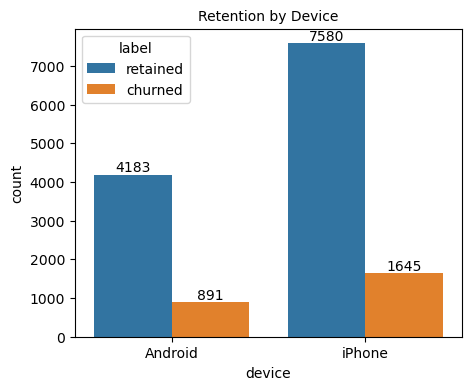

In [134]:
# How many iPhone users retained compared to Android
plt.figure(figsize =(5,4))
cnt = sn.countplot(x ='device', hue='label', data=wazedf)
for i in cnt.containers:
    cnt.bar_label(i)
plt.title("Retention by Device", fontsize=10)
plt.show()